In [1]:
!git clone https://github.com/KamilaKorczynska/VAE.git

Cloning into 'VAE'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 97 (delta 20), reused 92 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 4.01 MiB | 25.69 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [2]:
%cd /content/VAE

/content/VAE


In [3]:
seed = 42
batch_size = 64
image_size = 64

In [4]:
import random
import numpy as np
import torch

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [5]:
from src.utils.checkpoints import load_checkpoint
from src.utils.reconstructions import analyze_reconstrustions
from scripts.generate import generate_image
import matplotlib.pyplot as plt
from pathlib import Path
from src.datasets.Cat_dataset import CatDataset, transform
from torch.utils.data import DataLoader, random_split

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
data_dir = Path("/content/drive/MyDrive/Colab Notebooks/VAE/Cats")
checkpoint_path = Path("/content/drive/MyDrive/Colab Notebooks/VAE/checkpoints/mse_epoch200_latent64_lr0.001_3jpnigkn/best_checkpoint.pth")

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transforms = transform(image_size=image_size)
g = torch.Generator().manual_seed(seed)

full_dataset = CatDataset(
    image_dir=data_dir,
    transform=transforms
)
train_dataset, remaining_dataset = random_split(full_dataset, [0.7, 0.3], generator=g)
val_dataset, test_dataset = random_split(remaining_dataset, [0.5, 0.5], generator=g)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=g
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    generator=g
)

In [22]:
print(checkpoint_path)
print(checkpoint_path.exists())

/content/drive/MyDrive/Colab Notebooks/VAE/checkpoints/mse_epoch200_latent64_lr0.001_3jpnigkn/best_checkpoint.pth
True


In [9]:
model, optimizer, criterion, epoch, val_loss = load_checkpoint(checkpoint_path)

train_results = analyze_reconstrustions(model, train_dataloader, device, criterion)
val_results = analyze_reconstrustions(model, val_dataloader, device, criterion)

In [31]:
model, optimizer, criterion, epoch, val_loss = load_checkpoint(checkpoint_path, image_size, latent_dim, learning_rate)

In [32]:
print(epoch, val_loss)

40 210.73768657457836


In [10]:
def get_results(results):
  sorted_results = sorted(results, key=lambda x: x["reconstruction_loss"])
  middle = len(sorted_results) // 2

  best = sorted_results[:4]
  worst = sorted_results[-4:]
  average = sorted_results[middle -2 : middle +2]

  return best, average, worst

def show_results(results, save_path=None):
    for i in range(len(results)):
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))

        axes[0].imshow(results[i]["image"].permute(1, 2, 0))
        axes[1].imshow(results[i]["x_hat"].permute(1, 2, 0))

        axes[0].set_title("Original")
        axes[1].set_title(
            f'Reconstruction\nloss = {results[i]["reconstruction_loss"]:.2f}'
        )

        axes[0].axis("off")
        axes[1].axis("off")

        plt.tight_layout()

        if save_path is not None:
            fig.savefig(
                f"{save_path}_{i}.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

In [21]:
%cd "/content/drive/MyDrive/Colab Notebooks/VAE"

/content/drive/MyDrive/Colab Notebooks/VAE


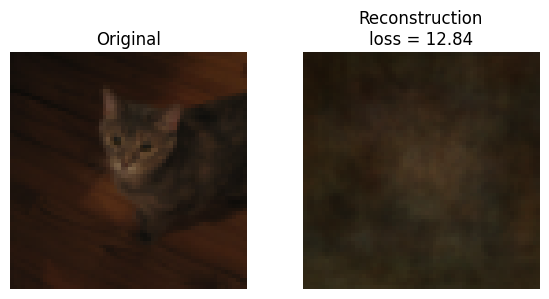

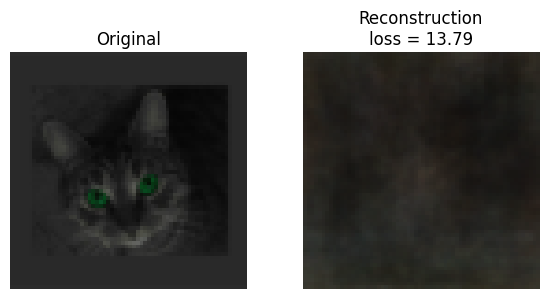

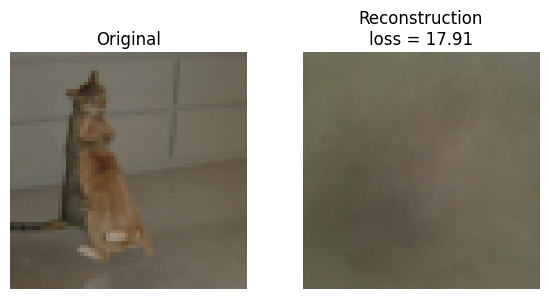

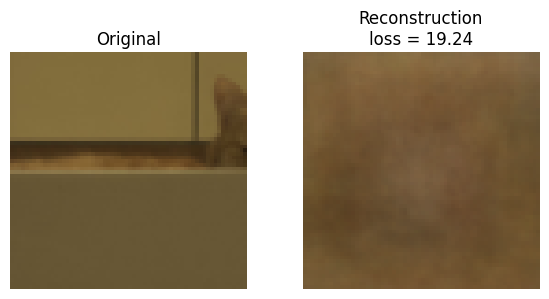

In [22]:
best, average, worst = get_results(train_results)
show_results(best, "train_best")

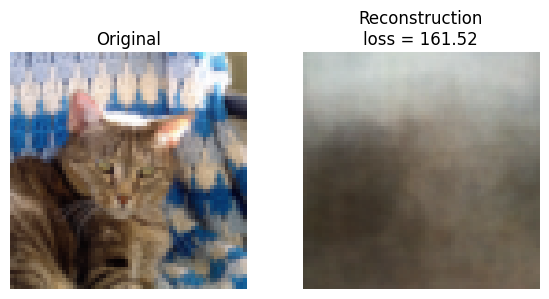

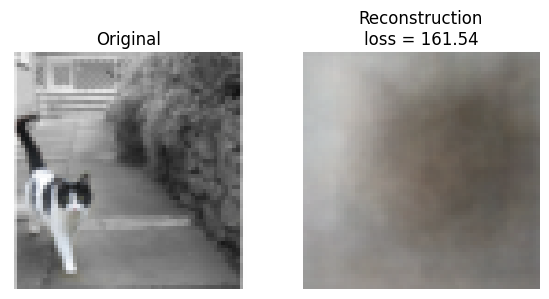

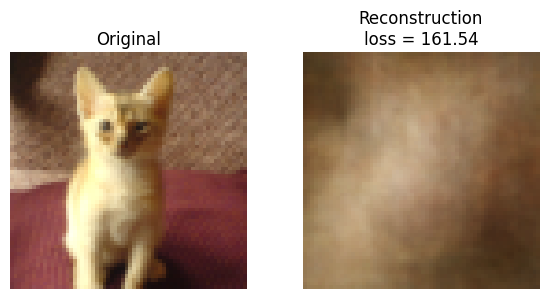

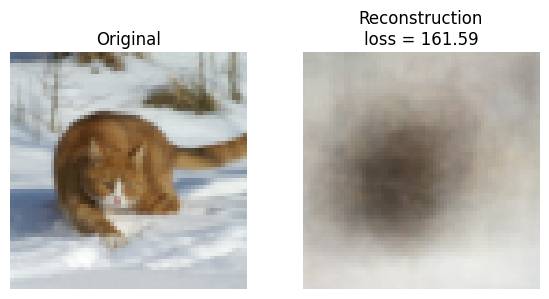

In [23]:
show_results(average, "train_average")

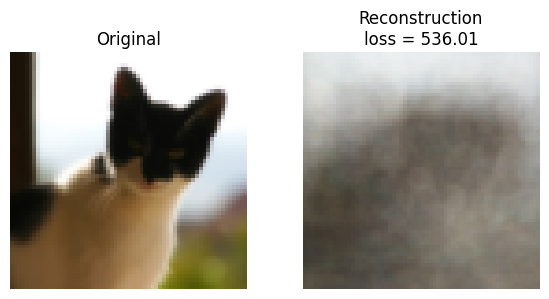

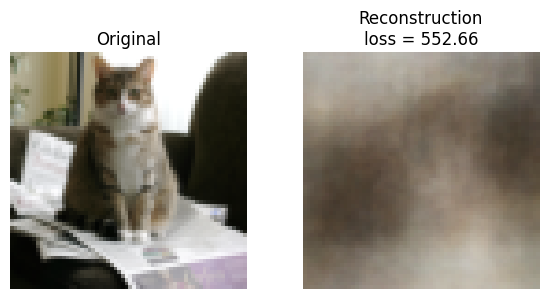

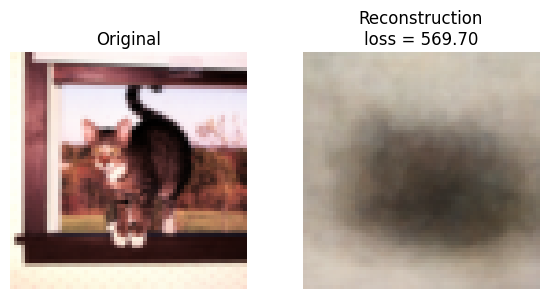

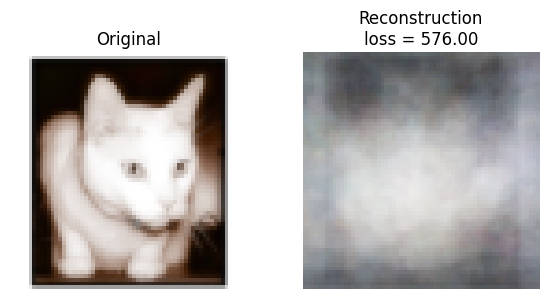

In [24]:
show_results(worst, "train_worst")

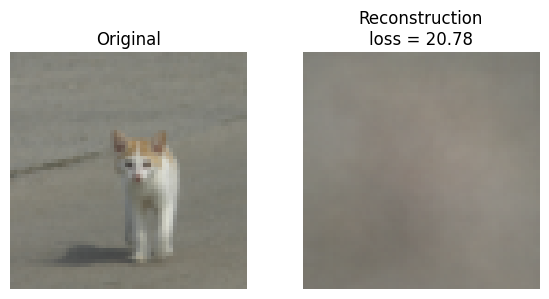

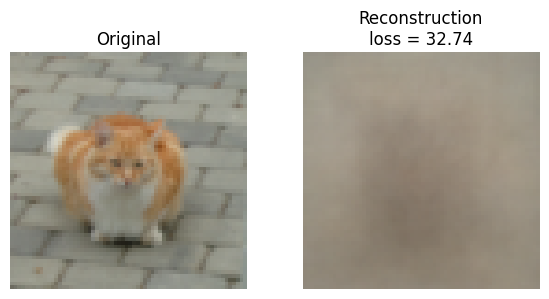

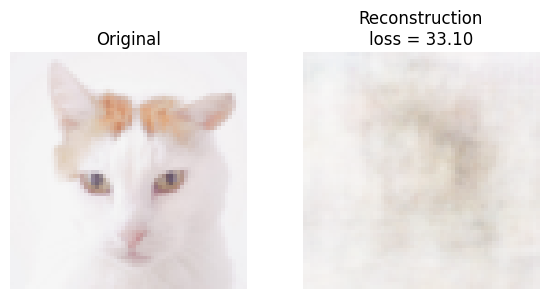

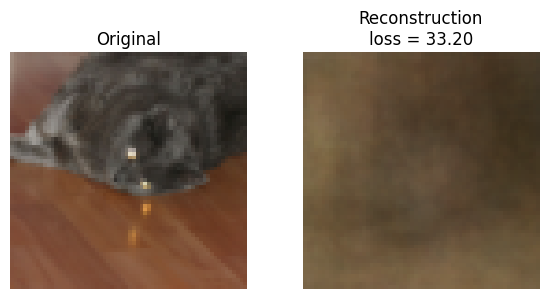

In [25]:
best, average, worst = get_results(val_results)
show_results(best, "val_best")

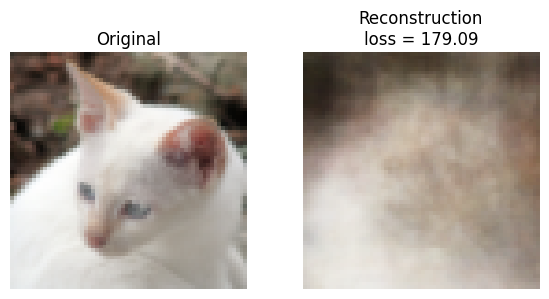

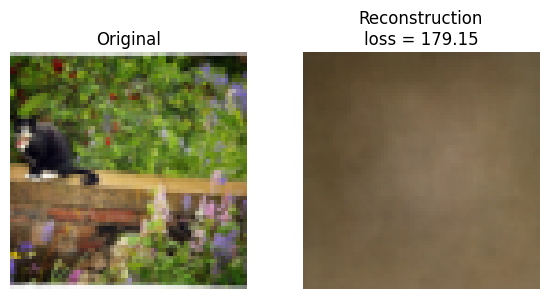

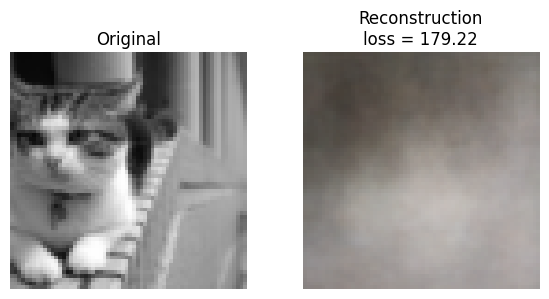

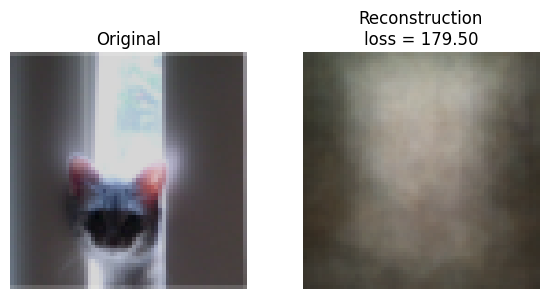

In [26]:
show_results(average, "val_average")

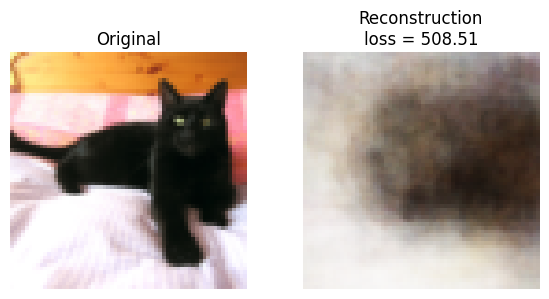

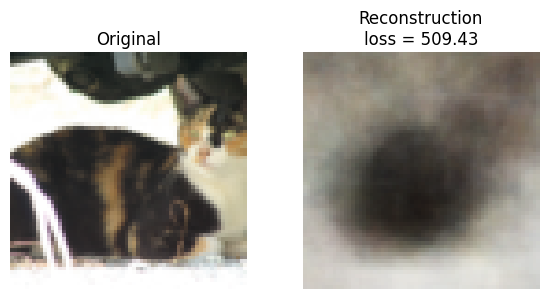

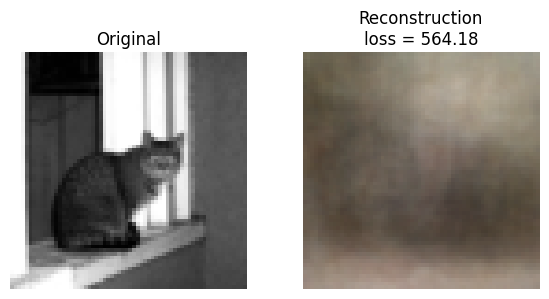

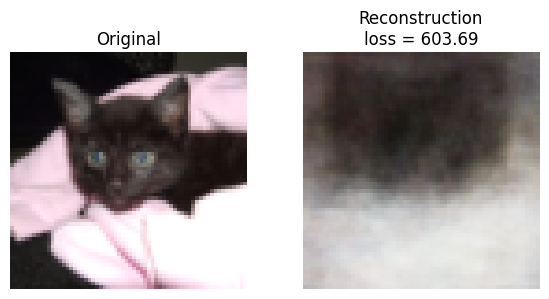

In [27]:
show_results(worst, "val_worst")

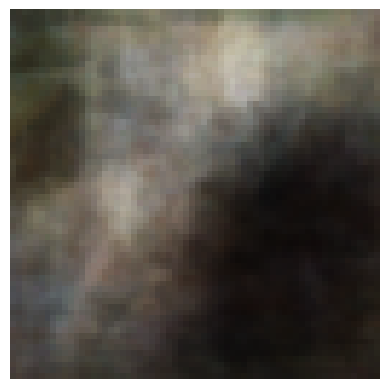

In [28]:
generated = generate_image(model, latent_dim, device)

image = generated.squeeze(0)
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.savefig("generated_sample.png", dpi=300, bbox_inches="tight")
plt.show()

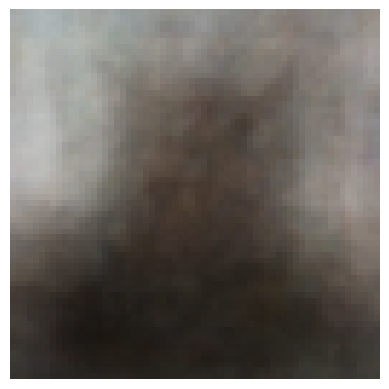

In [29]:
generated = generate_image(model, latent_dim, device)

image = generated.squeeze(0)
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.savefig("generated_sample_2.png", dpi=300, bbox_inches="tight")
plt.show()